# Training Neural Nets

1. Using Data Loaders.
2. Build and train a simple neural net w/o ReLU
3. Build and train a simple neural net with ReLU.
4. Non-linear level sets!

## Recap of Basic Ideas

1. Recall out basic ERM paradigm:
```
model = DecisionTreeClassifier(max_depth = 3)
```
```
model.fit(X,y)
```
```
model.predict(X_test)
```

2. The first command remains the same:
```
model = NeuralNet_WeDesign()
```
The second command takes more work to replace. It will be something like this, that we will write:
```
train(model,data,optimizer,epochs)
```
This training loop will run **gradient descent** or some variant of it, to find the weights of the neural network.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F



## Make some data

just like in previous notebook...

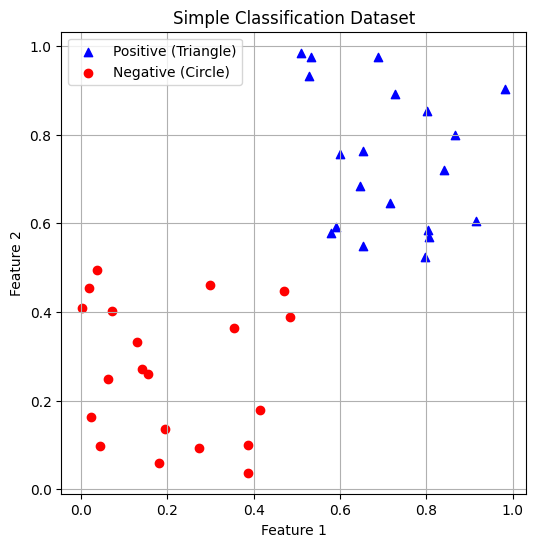

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Seed for reproducibility
np.random.seed(42)

# Generate positive examples in the upper right quadrant
X_positive = np.random.uniform(0.5,1.0,(20,2))

# Generate negative examples in the lower left quadrant
X_negative = np.random.uniform(0.0, 0.5,(20,2))

# Plotting the data
plt.figure(figsize=(6, 6))
plt.scatter(X_positive[:,0],X_positive[:,1], marker='^', color='blue', label='Positive (Triangle)')
plt.scatter(X_negative[:,0],X_negative[:,1], marker='o', color='red', label='Negative (Circle)')
plt.title('Simple Classification Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()


## Simply neural net family

We've seen this before...

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleClassifier(nn.Module):
    def __init__(self):
        super(SimpleClassifier, self).__init__()
        self.fc = nn.Linear(2, 2)  # Input dimension is 2, output dimension is 2 (one for each class)

    def forward(self, x):
        x = self.fc(x)
        return x # return logits -- note our loss function is now cross entropy


In [ ]:
model = SimpleClassifier()
# Set weights and biases -- similar (but not identical) to previous notebook
model.fc.weight = nn.Parameter(torch.tensor([[-1.0, 1.0], [1.0, -1.0]]))
model.fc.bias = nn.Parameter(torch.tensor([-0.0, 0.0]))


In [ ]:
# Select a few examples
points = torch.tensor([[0.1, 0.15],[0.8,0.8],[0.5,0.45]], dtype=torch.float32)

# Feed them through the network
outputs = model(points)

print("Outputs for selected points:\n", outputs)


Outputs for selected points:
 tensor([[ 0.0500, -0.0500],
        [ 0.0000,  0.0000],
        [-0.0500,  0.0500]], grad_fn=<AddmmBackward0>)


In [ ]:
# Function to plot decision boundaries
def plot_decision_boundary(model, X, y):

    # make a fine mesh grid of points and label them with model
    x_min, x_max = X[:,0].min(), X[:,0].max()
    y_min, y_max = X[:,1].min(), X[:,1].max()
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        probs = model(grid)
        Z = probs[:, 1] - probs[:, 0]
        Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap="RdBu", alpha=0.5)

    # Now plot the original points, along with their true label given in y
    # Extract positive and negative indices based on y
    positive_indices = np.where(y == 1)[0]
    negative_indices = np.where(y == 0)[0]

    # Split X into positive and negative components
    X_positive = X[positive_indices, :]
    X_negative = X[negative_indices, :]
    plt.scatter(X_positive[:,0], X_positive[:,1], marker='^', color='blue', label='Positive (Triangle)')
    plt.scatter(X_negative[:,0], X_negative[:,1], marker='o', color='red', label='Negative (Circle)')
    plt.title("Decision Region with Data Points")
    plt.show()

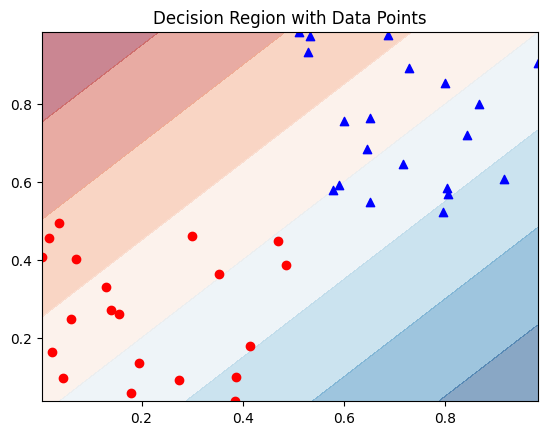

In [ ]:
X = np.vstack((X_positive,X_negative))
y = np.array([1]*20 + [0]*20)  # Correctly assigning labels to each class

plot_decision_boundary(model, X, y)

## These contours no good!



# Training: model.fit(X,y)

The things we need:

1. **Prepare the data**
  * Make sure we have torch tensors
  * Package the X and y into a torch dataset class.
  * Create a DataLoader that will hand data to our optimization loop.

2. **GPU:** We want to make sure we are working on a GPU.
  *  We need to properly set the runtime in Colab.
  * We need to make sure we send the model and the data to the GPU.
  * Note: all of numpy utilities, including matplotlib etc. work from data that live on the CPU, so if we are doing computations on the GPU, we need to pull them back to the CPU to use matplotlib.

3. **Training:** train(model, train_loader, optimizer, epochs)
  * This is a custom (but reusable) training function that we are going to write. It is essentially implementing a version of Gradient Descent.


### Data Loader



* Τutorial: https://pytorch.org/tutorials/beginner/basics/data_tutorial.html

* https://towardsdatascience.com/beginners-guide-to-loading-image-data-with-pytorch-289c60b7afec
* https://stackoverflow.com/questions/51756581/how-do-i-turn-a-pytorch-dataloader-into-a-numpy-array-to-display-image-data-with

* https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html



In [ ]:
from torch.utils.data import TensorDataset, DataLoader
import torch

# data (X,y) created above
tensor_x_train = torch.tensor(X, dtype=torch.float32) # transform to torch tensor
tensor_y_train = torch.tensor(y, dtype=torch.long)     # labels should be torch.long for classification

m = 32 # Batch size
data_train = TensorDataset(tensor_x_train, tensor_y_train) # create your dataset
train_loader = DataLoader(data_train, batch_size=m, shuffle=True) # create your dataloader with training data


### GPU

```
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
```

In [ ]:
# Set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Training

We write the following training function
```
train(model, train_loader, optimizer, epochs)
```
Here:

```model```

is our model,

```train_loader```

is our training data,

```optimizer```

is the algorithm (version of gradient descent)

```epochs```

number of passes through the data.


### Basic Training Steps

**Overview**
1. Ask Data Loader for some samples.
2. Push through the forward-block of the network to get ``y_pred``, with the current parameter settings.
3. Compute loss between ``y_pred`` and ``y``.
4. Perform a gradient step based in this loss.
5. Repeat, using new data from the Data Loader. When the data loader has gone through all the data once, this is the end of an ``epoch``. We repeat for however many epochs indicated.

### Some details in the code
1. ``device``: Tells Colab to use GPU or CPU.
2. ``model.to(device)``, ``x.to(device)``, ``y.to(device)``: these send the model weights, and the data to the right device. You will get an error if the weights are on one device and the data on another.
3. ``criterion = nn.NLLLoss``: this is the right loss function between ``y_pred`` and ``y`` when we are using log_softmax. The loss is computed using ``loss = criterion(outputs, y)``. If our model outputs logits, then we need to use ``criterion = nn.CrossEntropyLoss()''.
4. ``scheduler``: This controls the step size that gradient descent (or whichever version of GD we are using) takes. Our current code implements a piecewise constant scheduler: It stays constant for ``step_size`` epochs, and then decays by a factor of ``gamma``.

### Overall, the code here:

1. Trains the model.
2. Computes and saves the error at each step.
3. Creates the plots of loss and accuracy.


In [ ]:
from torch import optim
import torch
import copy
import torch.nn.functional as F
import matplotlib.pyplot as plt

def train(model, train_loader, optimizer, epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.9)
    train_losses = []
    train_accuracies = []  # List to store accuracy for each epoch
    best_accuracy = 0  # Best accuracy found
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y.long()) # compute the loss
            loss.backward() # compute the gradient over the batch of data
            optimizer.step() # take a step of the opt alg (e.g., SGD)
            scheduler.step()  # Update the learning rate
            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        model.eval()
        total_train_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                total_train_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        epoch_loss = total_train_loss / len(train_loader)
        epoch_accuracy = correct / total
        train_accuracies.append(epoch_accuracy)

        if epoch_accuracy > best_accuracy:
            best_accuracy = epoch_accuracy
            best_model_wts = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {train_losses[-1]}, Training Accuracy: {epoch_accuracy:.4f}")

    # Load best model weights
    model.load_state_dict(best_model_wts)
    print(f"Loaded the best model from epoch {best_epoch} with Training Accuracy: {best_accuracy:.4f}")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs+1), train_losses, label='Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs+1), train_accuracies, label='Training Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

    return


In [ ]:
# Set the random seed
torch.manual_seed(42)


In [ ]:
model = SimpleClassifier()
model.to(device)


SimpleClassifier(
  (fc): Linear(in_features=2, out_features=2, bias=True)
)

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.1)
epochs = 2

Epoch 1/2, Training Loss: 0.7599931359291077, Training Accuracy: 0.5000
Epoch 2/2, Training Loss: 0.7005781531333923, Training Accuracy: 0.5000
Loaded the best model from epoch 1 with Training Accuracy: 0.5000


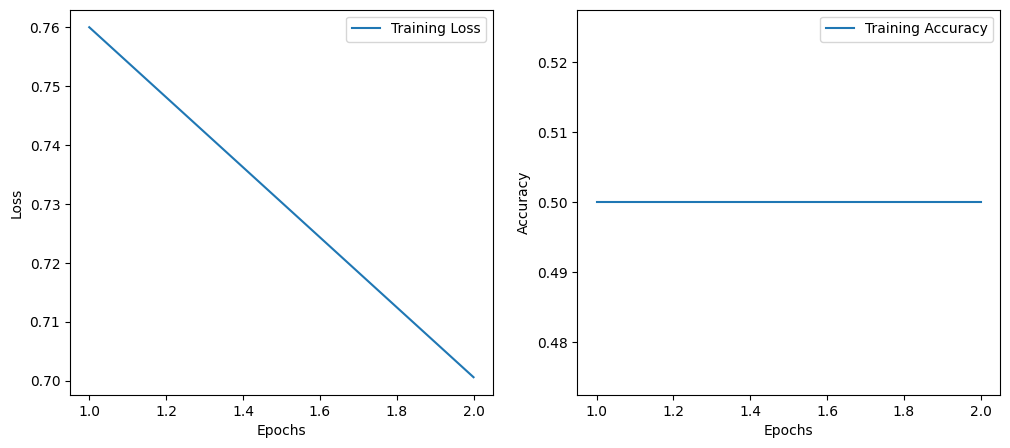

In [ ]:
torch.manual_seed(42)
train(model, train_loader,optimizer, epochs)


## How did we do?

**Not too well**.

Let's check the level sets of our model.

Note: $X$ and $y$ are on the CPU, but our model is on ``device`` which will be the GPU if we did things correctly. So we need to get the model back to the CPU. Then we can plot the decision boundary. Thus we have:
```
plot_decision_boundary(model.to('cpu'), X, y)
```

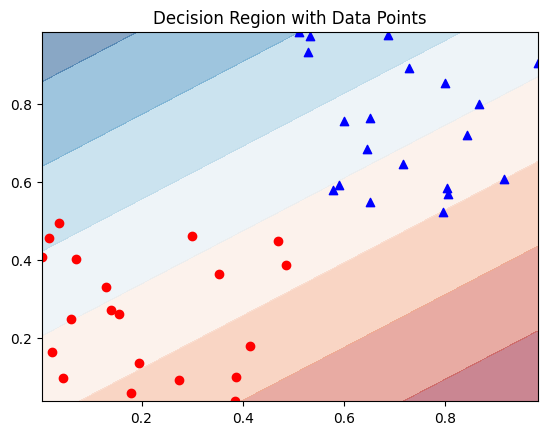

In [ ]:
plot_decision_boundary(model.to('cpu'), X, y)

# What should we do?

Give it some more time to search...

Epoch 1/10, Training Loss: 0.6608790755271912, Training Accuracy: 0.5000
Epoch 2/10, Training Loss: 0.6243506669998169, Training Accuracy: 0.6000
Epoch 3/10, Training Loss: 0.5447133183479309, Training Accuracy: 0.7500
Epoch 4/10, Training Loss: 0.5173251032829285, Training Accuracy: 0.8750
Epoch 5/10, Training Loss: 0.456529825925827, Training Accuracy: 0.9250
Epoch 6/10, Training Loss: 0.3805437684059143, Training Accuracy: 0.9500
Epoch 7/10, Training Loss: 0.37328745424747467, Training Accuracy: 0.9750
Epoch 8/10, Training Loss: 0.3462873101234436, Training Accuracy: 0.9750
Epoch 9/10, Training Loss: 0.30961641669273376, Training Accuracy: 0.9750
Epoch 10/10, Training Loss: 0.26517871767282486, Training Accuracy: 0.9750
Loaded the best model from epoch 7 with Training Accuracy: 0.9750


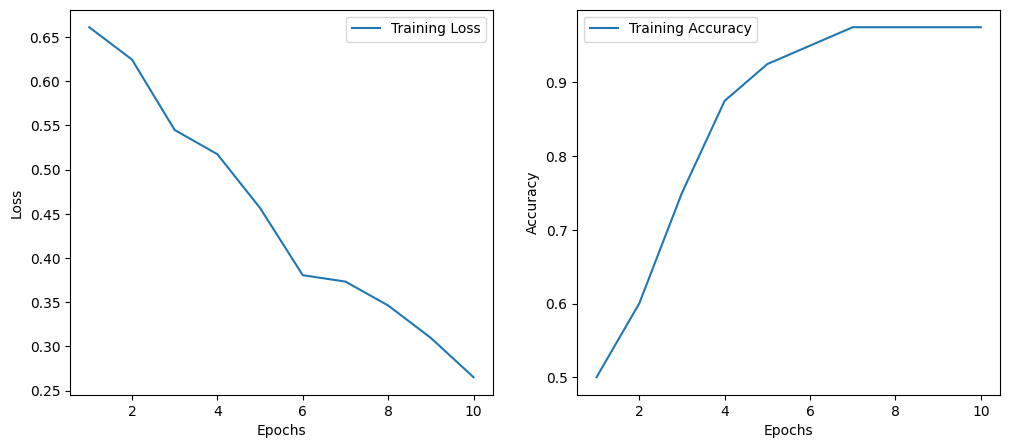

In [ ]:
torch.manual_seed(42)
epochs = 10
train(model, train_loader, optimizer, epochs)


## Looks much better!



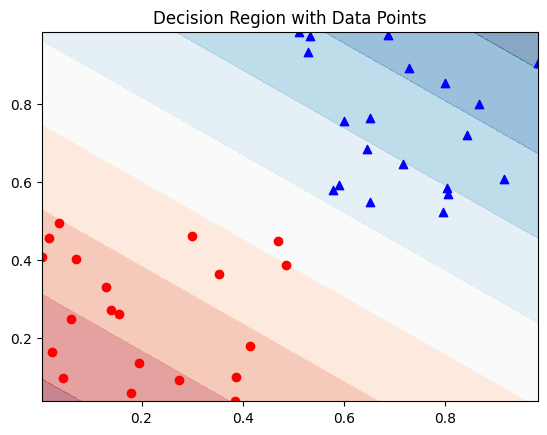

In [ ]:
plot_decision_boundary(model.to('cpu'), X, y)

## We could continue to run it...


Epoch 1/10, Training Loss: 0.32394392788410187, Training Accuracy: 0.9500
Epoch 2/10, Training Loss: 0.2929612696170807, Training Accuracy: 0.9500
Epoch 3/10, Training Loss: 0.26252470165491104, Training Accuracy: 0.9500
Epoch 4/10, Training Loss: 0.26403799653053284, Training Accuracy: 0.9500
Epoch 5/10, Training Loss: 0.2381509393453598, Training Accuracy: 0.9750
Epoch 6/10, Training Loss: 0.20058204233646393, Training Accuracy: 0.9750
Epoch 7/10, Training Loss: 0.21362058073282242, Training Accuracy: 0.9750
Epoch 8/10, Training Loss: 0.21099209785461426, Training Accuracy: 1.0000
Epoch 9/10, Training Loss: 0.19243132323026657, Training Accuracy: 1.0000
Epoch 10/10, Training Loss: 0.16696055233478546, Training Accuracy: 1.0000
Loaded the best model from epoch 8 with Training Accuracy: 1.0000


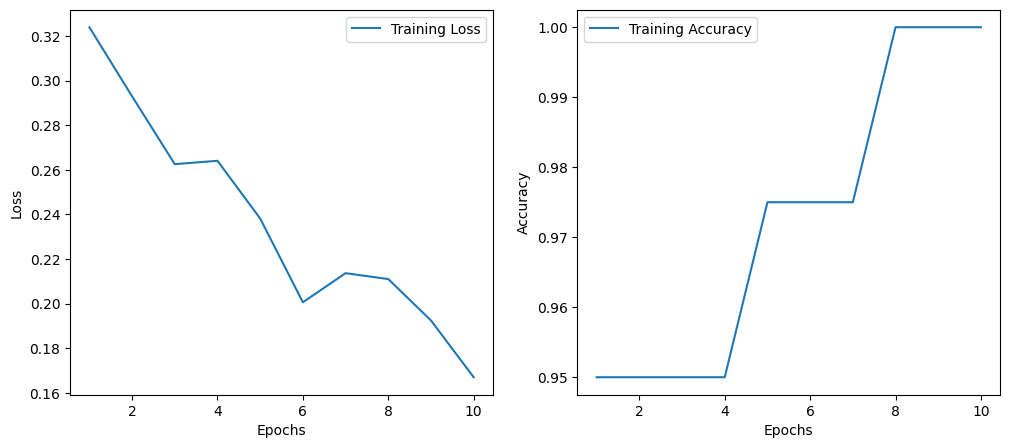

In [ ]:
torch.manual_seed(42)
epochs = 10
train(model, train_loader,optimizer, epochs)

### What weights did we find?

It is useful to know how to access the weights of a trained model.
```
# Access the state dictionary
state_dict = model.state_dict()

# Get weights and biases of model.fc
fc_weights = state_dict['fc.weight']
fc_biases = state_dict['fc.bias']

# Print or use them
print(fc_weights)
print(fc_biases)
```

In [ ]:
model.fc.weight

Parameter containing:
tensor([[-1.5591, -1.3283],
        [ 1.9340,  2.5647]], device='cuda:0', requires_grad=True)

In [ ]:
# Access the state dictionary
state_dict = model.state_dict()

# Get weights and biases of model.fc
fc_weights = state_dict['fc.weight']
fc_biases = state_dict['fc.bias']

# Print or use them
print(fc_weights)
print(fc_biases)


tensor([[-1.5591, -1.3283],
        [ 1.9340,  2.5647]], device='cuda:0')
tensor([ 1.6868, -1.6990], device='cuda:0')


# Observations

1. For the first five epochs, nothing much was happening.
2. It took a number of epochs to get to a good solution.
3. In the end, we succeeded (gradient descent succeeded) in finding a good solution.

# Second Example

Let's see something a little more interesting

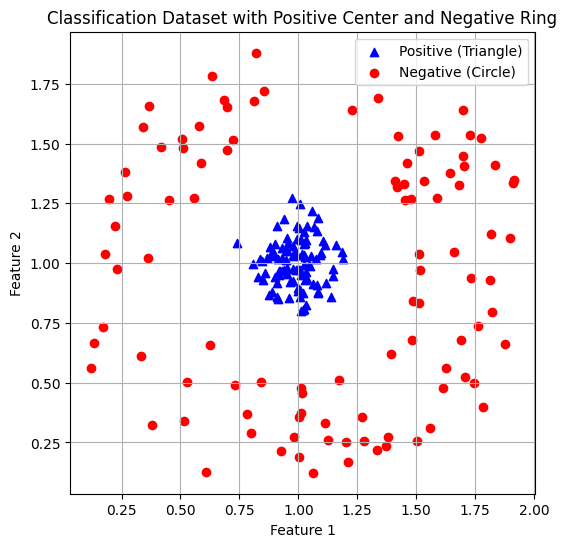

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Seed for reproducibility
np.random.seed(42)

# Generate positive examples centered around (1,1)
positive_x = 0.1 * np.random.randn(100, 2) + 1

# Generate negative examples in a ring-like structure
radius = 0.5 + 0.5 * np.random.rand(100, 1)
angle = 2 * np.pi * np.random.rand(100, 1)
negative_x = np.hstack((radius * np.cos(angle), radius * np.sin(angle))) + 1

# Plotting the data
plt.figure(figsize=(6, 6))
plt.scatter(positive_x[:, 0], positive_x[:, 1], marker='^', color='blue', label='Positive (Triangle)')
plt.scatter(negative_x[:, 0], negative_x[:, 1], marker='o', color='red', label='Negative (Circle)')
plt.title('Classification Dataset with Positive Center and Negative Ring')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()


## Our current network won't work

We already know this!

### But let's try anyway

We need a new Data Loader



In [ ]:
# Correctly stacking the data points
X2 = np.vstack([positive_x, negative_x])
y2 = np.array([1]*positive_x.shape[0] + [0]*negative_x.shape[0])  # Correctly assigning labels to each class

In [ ]:
tensor_x_train2 = torch.tensor(X2, dtype=torch.float32) # transform to torch tensor
tensor_y_train2 = torch.tensor(y2, dtype=torch.long)     # labels should be torch.long for classification

m = 32 # Batch size
data_train2 = TensorDataset(tensor_x_train2, tensor_y_train2) # create your dataset
train_loader2 = DataLoader(data_train2, batch_size=m, shuffle=True) # create your dataloader with training data

In [ ]:
model = SimpleClassifier()
model.to(device)

SimpleClassifier(
  (fc): Linear(in_features=2, out_features=2, bias=True)
)

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.1)
epochs = 200 # plenty of time if it's going to work...

## Train

Epoch 1/200, Training Loss: 0.7264720712389264, Training Accuracy: 0.5000
Epoch 2/200, Training Loss: 0.7224164945738656, Training Accuracy: 0.6100
Epoch 3/200, Training Loss: 0.7001501321792603, Training Accuracy: 0.3700
Epoch 4/200, Training Loss: 0.6859904442514692, Training Accuracy: 0.3750
Epoch 5/200, Training Loss: 0.6850008198193142, Training Accuracy: 0.3600
Epoch 6/200, Training Loss: 0.6796231099537441, Training Accuracy: 0.7350
Epoch 7/200, Training Loss: 0.6840879917144775, Training Accuracy: 0.5850
Epoch 8/200, Training Loss: 0.6889434371675763, Training Accuracy: 0.4650
Epoch 9/200, Training Loss: 0.6764468465532575, Training Accuracy: 0.7300
Epoch 10/200, Training Loss: 0.7001188482557025, Training Accuracy: 0.6700
Epoch 11/200, Training Loss: 0.6934223856244769, Training Accuracy: 0.4100
Epoch 12/200, Training Loss: 0.6936774935041156, Training Accuracy: 0.6950
Epoch 13/200, Training Loss: 0.6667098913873944, Training Accuracy: 0.3550
Epoch 14/200, Training Loss: 0.681

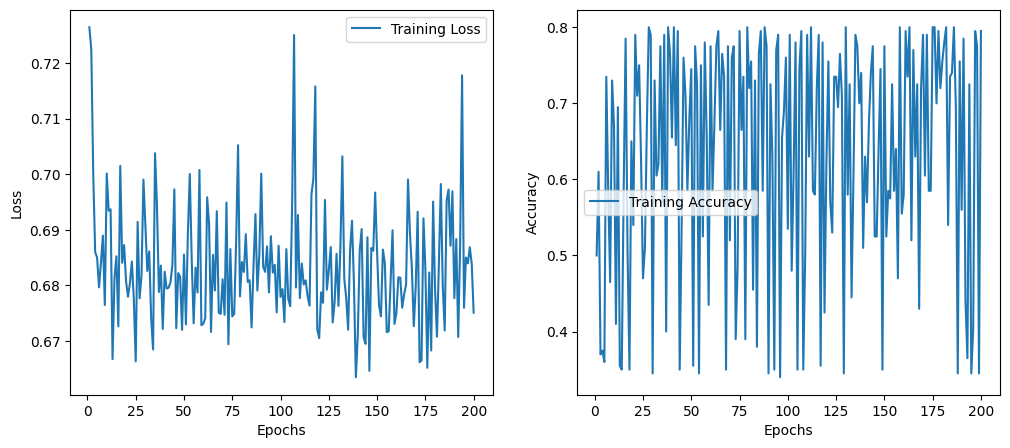

In [ ]:
torch.manual_seed(42)
train(model, train_loader2, optimizer, epochs)


## Didn't work (as we already expected)



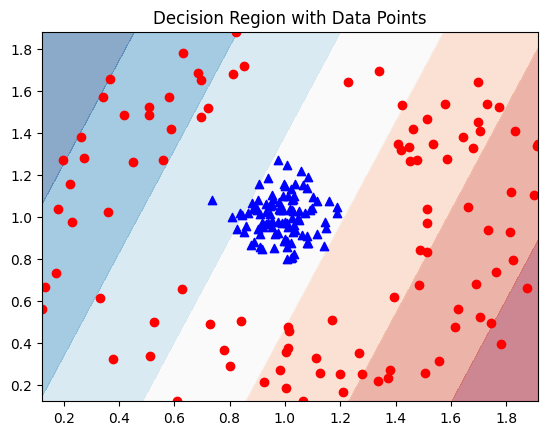

In [ ]:
plot_decision_boundary(model.to('cpu'), X2, y2)

# Non-linear data require non-linear network!

Option 1: A Classical Outlook.

We have already seen this problem before, and saw that we can deal with it using **feature engineering**. With our clever intuition, we can see that we should likely add some quadratic features.

Recall that what we are doing here, is designing a non-linear transformation such that in this new transormed space, the data are now linearly separable.

To do this, we could either do our data augmentation in ``numpy`` as we did when we used sklearn, and then repeat our entire process of creating torch tensors, datasets and dataloaders, and then define a neural network that accepts 4 inputs. OR we could package this all into the forward method, and re-use our old dataloaders. Let's take this latter approach.



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AugmentingLinearClassifier(nn.Module):
    def __init__(self):
        super(AugmentingLinearClassifier, self).__init__()
        self.fc = nn.Linear(4, 2)  # Input dimension is 4, output dimension is 2

    def forward(self, x):
        # x is 2-dimensional, augment it to 4-dimensional
        x_squared1 = x[:, 0:1]**2
        x_squared2 = x[:, 1:2]**2
        x_augmented = torch.cat((x, x_squared1, x_squared2), dim=1)

        x = self.fc(x_augmented)
        return x  # again returning logits

    def predict(self,x):
        x = self.forward(x)
        predictions = torch.argmax(x, dim=-1)
        return predictions.cpu().detach().numpy() if x.is_cuda else predictions.detach().numpy()

Epoch 1/200, Training Loss: 0.8234402026448931, Training Accuracy: 0.5000
Epoch 2/200, Training Loss: 0.6936789495604379, Training Accuracy: 0.7250
Epoch 3/200, Training Loss: 0.6658836858613151, Training Accuracy: 0.7750
Epoch 4/200, Training Loss: 0.642733267375401, Training Accuracy: 0.4100
Epoch 5/200, Training Loss: 0.6363591551780701, Training Accuracy: 0.7000
Epoch 6/200, Training Loss: 0.6154717377253941, Training Accuracy: 0.7550
Epoch 7/200, Training Loss: 0.6018120646476746, Training Accuracy: 0.7200
Epoch 8/200, Training Loss: 0.612240765775953, Training Accuracy: 0.5550
Epoch 9/200, Training Loss: 0.5946127431733268, Training Accuracy: 0.7450
Epoch 10/200, Training Loss: 0.6074448313031878, Training Accuracy: 0.7650
Epoch 11/200, Training Loss: 0.5825410229819161, Training Accuracy: 0.7200
Epoch 12/200, Training Loss: 0.5638431438377925, Training Accuracy: 0.7500
Epoch 13/200, Training Loss: 0.5692732759884426, Training Accuracy: 0.7700
Epoch 14/200, Training Loss: 0.56254

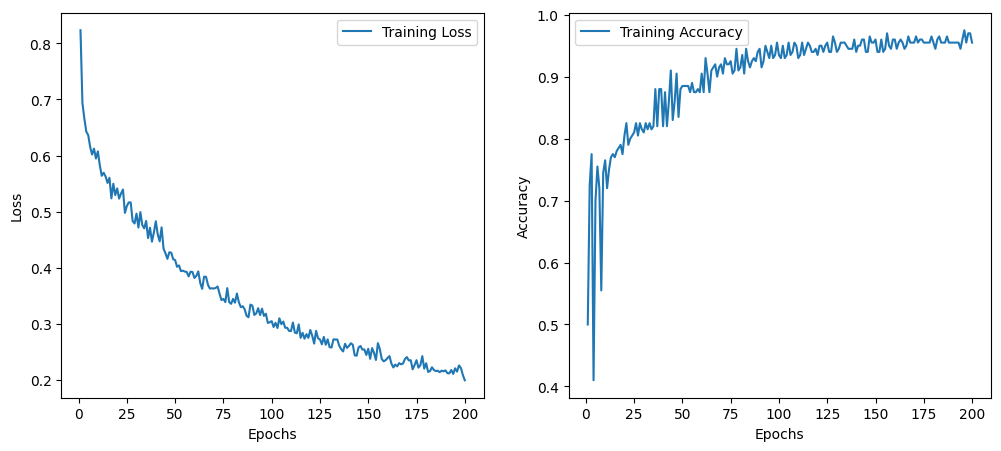

In [ ]:
model = AugmentingLinearClassifier()
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.05)
epochs = 200 # plenty of time if it's going to work...

torch.manual_seed(2)
train(model, train_loader2, optimizer, epochs)

In [ ]:
# compute accuracy
predictions = model.predict(tensor_x_train2.to(device))
print(predictions)

# compute accuracy compared to y2
accuracy = (predictions == y2).mean()
print(f"Accuracy: {accuracy * 100:.2f}%")

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Accuracy: 97.50%


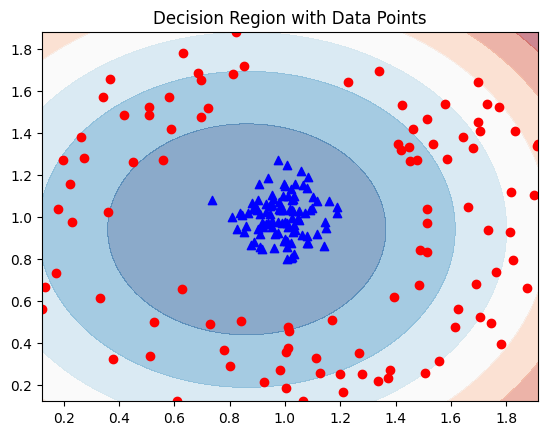

In [ ]:
plot_decision_boundary(model.to('cpu'), X2, y2)

# Non-linear data require non-linear network! Take 2
Option 2: A modern Neural Network Outlook.

We are going to define a **non-linear** neural network which we now know how to do -- more than one layer, and non-linear activation function such as ``ReLU``. This process is essentially using gradient descent in order to find a transformation after which the data are linearly separable. Remember this perspective, as we will see it many times and in more sophistication.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DeeperNet(nn.Module):
    def __init__(self):
        super(DeeperNet, self).__init__()
        self.fc1 = nn.Linear(2, 10)  # First layer, from 2 inputs to 10 outputs
        self.fc2 = nn.Linear(10, 10) # Second layer, 10 to 10
        self.fc3 = nn.Linear(10, 2)  # Output layer, from 10 to 2 outputs
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x # we are returning logits, hence need to use nn.CrossEntropyLoss()


In [ ]:
# Set the random seed
torch.manual_seed(64)

In [ ]:
model = DeeperNet()
model.to(device)


DeeperNet(
  (fc1): Linear(in_features=2, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=10, bias=True)
  (fc3): Linear(in_features=10, out_features=2, bias=True)
  (relu): ReLU()
)

In [ ]:
model.fc2.weight

Parameter containing:
tensor([[-0.0393,  0.2909,  0.1767, -0.0933, -0.0148, -0.0690, -0.0271,  0.1657,
          0.2956,  0.2767],
        [ 0.0583, -0.1868, -0.0007, -0.2790, -0.2331, -0.1457, -0.0265, -0.0864,
         -0.0571,  0.2979],
        [ 0.0888, -0.1149,  0.1230, -0.1557, -0.0220,  0.2747,  0.2956,  0.0374,
         -0.2614,  0.3097],
        [ 0.1635,  0.0828, -0.2938, -0.2757, -0.0117,  0.0808,  0.2688,  0.2738,
         -0.1834, -0.2460],
        [ 0.0664, -0.2107, -0.1583,  0.0988, -0.1000, -0.3139, -0.0786, -0.1459,
          0.2474, -0.2386],
        [ 0.1059,  0.2988, -0.1609,  0.2075,  0.0382,  0.1462,  0.2784,  0.2195,
          0.0139,  0.2980],
        [ 0.1510, -0.1937, -0.1464,  0.2853,  0.3046,  0.2683, -0.2128, -0.0057,
          0.0054, -0.1081],
        [-0.1528, -0.1279, -0.2404,  0.0967,  0.0635,  0.1164, -0.1077,  0.0485,
         -0.3009,  0.1713],
        [ 0.1225,  0.2134,  0.2771, -0.0898,  0.2904,  0.2948, -0.2010,  0.0868,
         -0.2971, -0.3119

Epoch 1/3, Training Loss: 0.701726394040244, Training Accuracy: 0.5000
Epoch 2/3, Training Loss: 0.6362122893333435, Training Accuracy: 0.9600
Epoch 3/3, Training Loss: 0.4776539334229061, Training Accuracy: 0.9900
Loaded the best model from epoch 3 with Training Accuracy: 0.9900


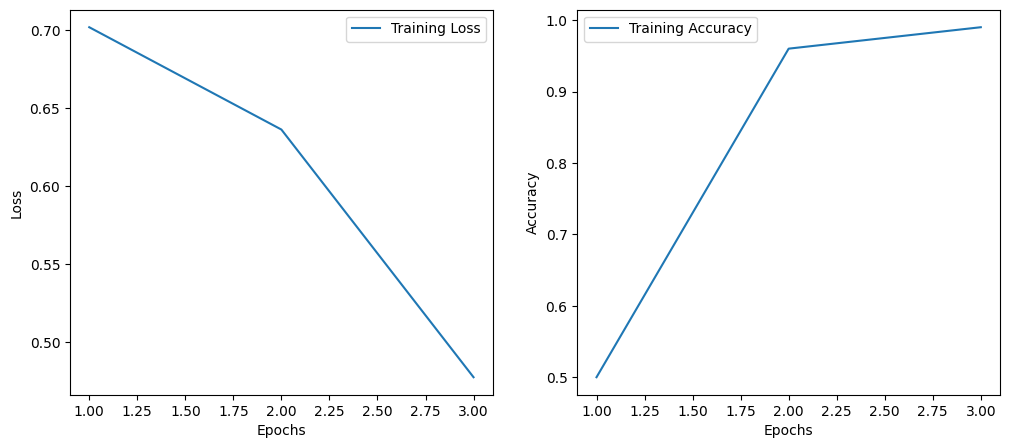

In [ ]:
torch.manual_seed(64)
optimizer = optim.Adam(model.parameters(), lr=0.05)
epochs = 3
train(model, train_loader2, optimizer, epochs)


## Let's run a little longer

Epoch 1/10, Training Loss: 0.36900433897972107, Training Accuracy: 0.9350
Epoch 2/10, Training Loss: 0.250800650034632, Training Accuracy: 0.9900
Epoch 3/10, Training Loss: 0.15917321826730454, Training Accuracy: 0.9850
Epoch 4/10, Training Loss: 0.10156561008521489, Training Accuracy: 1.0000
Epoch 5/10, Training Loss: 0.05091962989951883, Training Accuracy: 1.0000
Epoch 6/10, Training Loss: 0.02844182282154049, Training Accuracy: 0.9950
Epoch 7/10, Training Loss: 0.019507959751146182, Training Accuracy: 1.0000
Epoch 8/10, Training Loss: 0.012148275539012892, Training Accuracy: 1.0000
Epoch 9/10, Training Loss: 0.010022274750683988, Training Accuracy: 1.0000
Epoch 10/10, Training Loss: 0.005368083956584867, Training Accuracy: 1.0000
Loaded the best model from epoch 4 with Training Accuracy: 1.0000


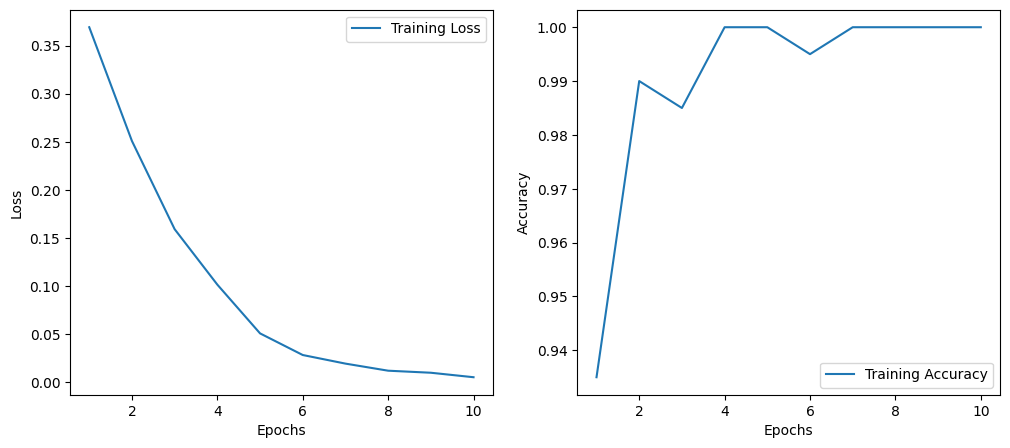

In [ ]:
torch.manual_seed(64)
optimizer = optim.Adam(model.parameters(), lr=0.05)
epochs = 10
train(model, train_loader2, optimizer, epochs)


## Much Better!


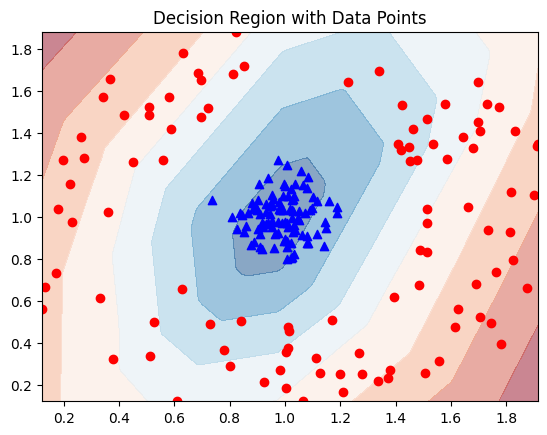

In [ ]:
plot_decision_boundary(model.to('cpu'), X2, y2)

## Non-linear level sets!

Recall that we did this manually by inspection in the first half of the class, by clever (hand-tuned) feature engineering.

Now, gradient descent has succeeded in doing this step for us!

# Deeper network

We use ``BatchNorm1d`` [Batch Normalization](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html)

In [ ]:
class EnhancedNet(nn.Module):
    def __init__(self):
        super(EnhancedNet, self).__init__()
        self.fc1 = nn.Linear(2, 20)  # Increase width
        self.bn1 = nn.BatchNorm1d(20)  # Batch normalization
        self.fc2 = nn.Linear(20, 40)
        self.bn2 = nn.BatchNorm1d(40)
        self.fc3 = nn.Linear(40, 40)
        self.bn3 = nn.BatchNorm1d(40)
        self.fc4 = nn.Linear(40, 20)
        self.bn4 = nn.BatchNorm1d(20)
        self.fc5 = nn.Linear(20, 2)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.fc3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.fc4(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.fc5(x)
        return x


In [ ]:
# Set the random seed
torch.manual_seed(42)

In [ ]:
model = EnhancedNet()
model.to(device)


EnhancedNet(
  (fc1): Linear(in_features=2, out_features=20, bias=True)
  (bn1): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=20, out_features=40, bias=True)
  (bn2): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=40, out_features=40, bias=True)
  (bn3): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=40, out_features=20, bias=True)
  (bn4): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc5): Linear(in_features=20, out_features=2, bias=True)
)

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.05, weight_decay=1e-4)
epochs = 50

Epoch 1/50, Training Loss: 0.2716026343405247, Training Accuracy: 0.4550
Epoch 2/50, Training Loss: 0.24182836458619153, Training Accuracy: 0.9100
Epoch 3/50, Training Loss: 0.07544262447793569, Training Accuracy: 0.9600
Epoch 4/50, Training Loss: 0.06632963408316885, Training Accuracy: 0.9700
Epoch 5/50, Training Loss: 0.015352893354637282, Training Accuracy: 0.9850
Epoch 6/50, Training Loss: 0.025116881289120232, Training Accuracy: 0.9900
Epoch 7/50, Training Loss: 0.179876710121919, Training Accuracy: 0.9900
Epoch 8/50, Training Loss: 0.11129741743206978, Training Accuracy: 0.7750
Epoch 9/50, Training Loss: 0.11318709568253585, Training Accuracy: 0.9400
Epoch 10/50, Training Loss: 0.23777163800384318, Training Accuracy: 1.0000
Epoch 11/50, Training Loss: 0.19989938555019243, Training Accuracy: 0.9750
Epoch 12/50, Training Loss: 0.08440778351255826, Training Accuracy: 0.9050
Epoch 13/50, Training Loss: 0.1272365309830223, Training Accuracy: 0.9900
Epoch 14/50, Training Loss: 0.066483

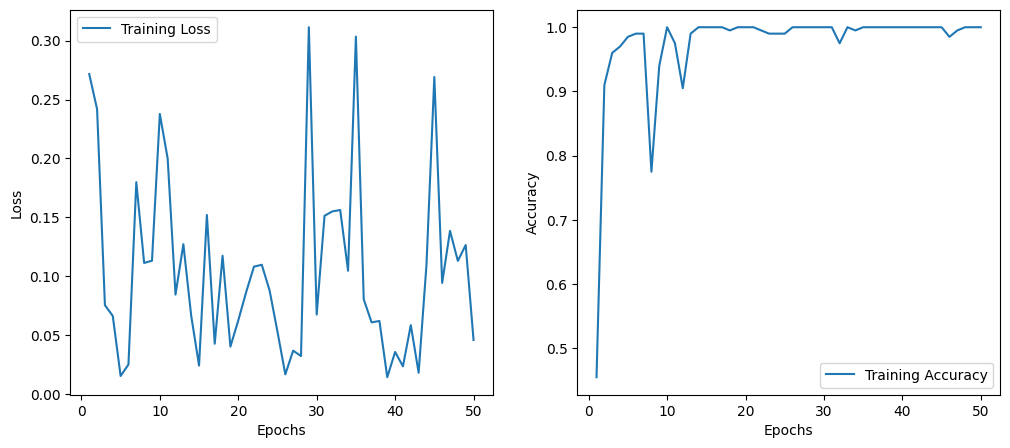

In [ ]:
train(model, train_loader2, optimizer, epochs)


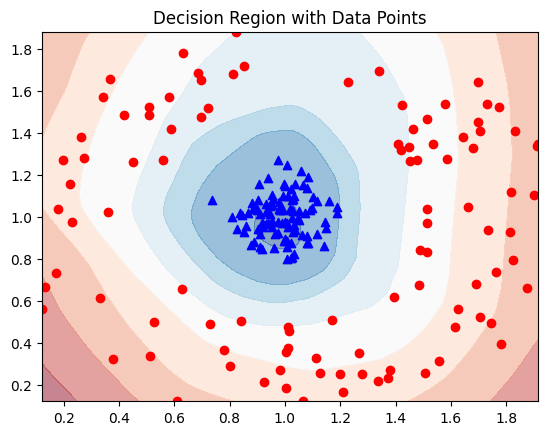

In [ ]:
plot_decision_boundary(model.to('cpu'), X2, y2)

# How many parameters?

In [ ]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

num_params = count_trainable_parameters(model)
print(f"Number of trainable parameters: {num_params}")


Number of trainable parameters: 3642


## Different Seeds

Each time we give the command
```
model = DeeperNet()
```
our model resets the weights with a random initialization. By trying this a few times, we see that there is a dependence on the initial weights, even in this simple (low-dimensional) example.

In [ ]:
torch.manual_seed(64)
model = DeeperNet()
model.to(device)

DeeperNet(
  (fc1): Linear(in_features=2, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=10, bias=True)
  (fc3): Linear(in_features=10, out_features=2, bias=True)
  (relu): ReLU()
)

Epoch 1/15, Training Loss: 0.701726394040244, Training Accuracy: 0.5000
Epoch 2/15, Training Loss: 0.6362122893333435, Training Accuracy: 0.9600
Epoch 3/15, Training Loss: 0.4776539334229061, Training Accuracy: 0.9900
Epoch 4/15, Training Loss: 0.29748745262622833, Training Accuracy: 0.9950
Epoch 5/15, Training Loss: 0.13434614453996932, Training Accuracy: 0.9850
Epoch 6/15, Training Loss: 0.07779755310288497, Training Accuracy: 0.9950
Epoch 7/15, Training Loss: 0.044477883859404495, Training Accuracy: 1.0000
Epoch 8/15, Training Loss: 0.041431092923241, Training Accuracy: 0.9800
Epoch 9/15, Training Loss: 0.03324160778096744, Training Accuracy: 1.0000
Epoch 10/15, Training Loss: 0.022907889348321726, Training Accuracy: 1.0000
Epoch 11/15, Training Loss: 0.007751476235820779, Training Accuracy: 0.9950
Epoch 12/15, Training Loss: 0.00992986247209566, Training Accuracy: 1.0000
Epoch 13/15, Training Loss: 0.006086045942668404, Training Accuracy: 1.0000
Epoch 14/15, Training Loss: 0.003748

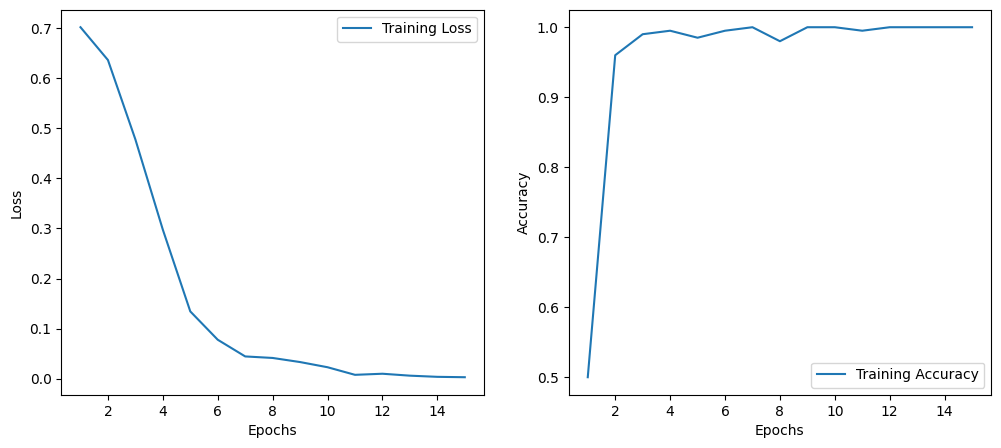

In [ ]:
torch.manual_seed(64)
optimizer = optim.Adam(model.parameters(), lr=0.05)
epochs = 15
train(model, train_loader2, optimizer, epochs)


# Different random seed

```
torch.manual_seed(42)
```

In [ ]:
torch.manual_seed(42)
model = DeeperNet()
model.to(device)

DeeperNet(
  (fc1): Linear(in_features=2, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=10, bias=True)
  (fc3): Linear(in_features=10, out_features=2, bias=True)
  (relu): ReLU()
)

Epoch 1/150, Training Loss: 0.7119825312069484, Training Accuracy: 0.5000
Epoch 2/150, Training Loss: 0.7029742428234645, Training Accuracy: 0.5000
Epoch 3/150, Training Loss: 0.684981916631971, Training Accuracy: 0.6450
Epoch 4/150, Training Loss: 0.6633208819798061, Training Accuracy: 0.4650
Epoch 5/150, Training Loss: 0.6243733167648315, Training Accuracy: 0.8700
Epoch 6/150, Training Loss: 0.5094229621546609, Training Accuracy: 0.8350
Epoch 7/150, Training Loss: 0.4014005277838026, Training Accuracy: 0.9150
Epoch 8/150, Training Loss: 0.28869920330388205, Training Accuracy: 0.9200
Epoch 9/150, Training Loss: 0.24216944724321365, Training Accuracy: 0.9450
Epoch 10/150, Training Loss: 0.1860541488443102, Training Accuracy: 0.9350
Epoch 11/150, Training Loss: 0.19619385259492056, Training Accuracy: 0.9250
Epoch 12/150, Training Loss: 0.21791312737124308, Training Accuracy: 0.8500
Epoch 13/150, Training Loss: 0.31207448669842314, Training Accuracy: 0.9200
Epoch 14/150, Training Loss: 0

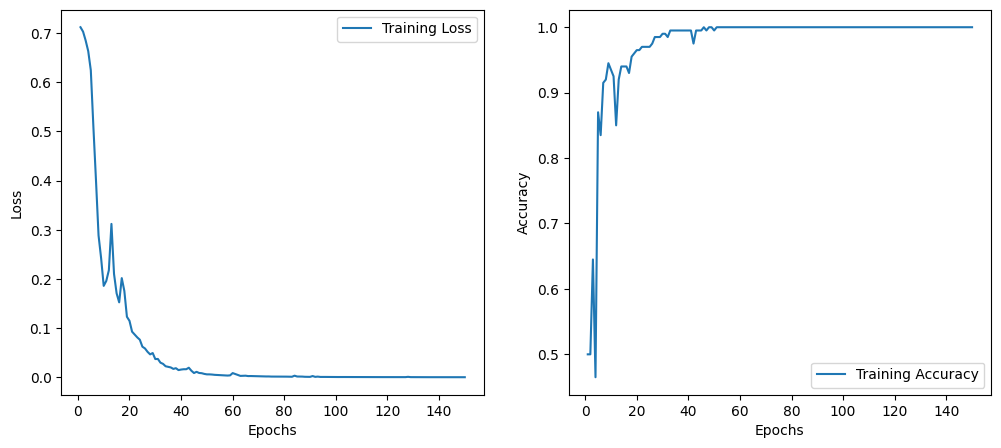

In [ ]:
torch.manual_seed(42)
optimizer = optim.Adam(model.parameters(), lr=0.05)
epochs = 150
train(model, train_loader2, optimizer, epochs)

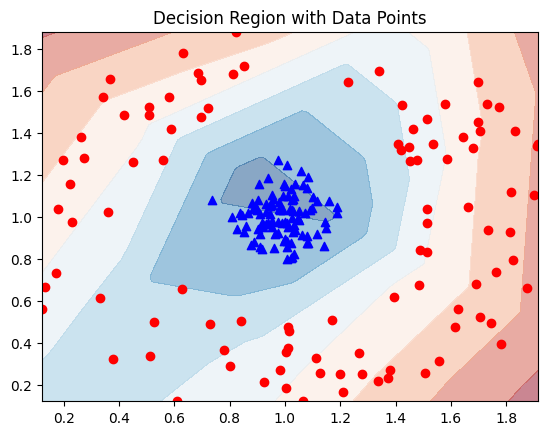

In [ ]:
plot_decision_boundary(model.to('cpu'), X2, y2)